# Conversion Heatmaps Across EEG, MEG, and fMRI

This notebook visualizes cross-modality conversion results for all available subject pairs.

It reads the aggregated file at `../results/summary/conversion_by_pair.csv`, expands both directions from each saved conversion result, and renders:

- subject-pair heatmaps for each directed modality pair
- modality-level overview matrices using mean and standard deviation across subject pairs

Before running this notebook, regenerate the summary outputs if needed:

```bash
./.venv/bin/python scripts/summarize_results.py
```

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RESULTS_PATH = Path('../results/summary/conversion_by_pair.csv')
OUTPUT_DIR = Path('../results/summary/figures')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
assert RESULTS_PATH.exists(), f'Missing summary CSV: {RESULTS_PATH}'

PAIR_ORDER = [
    ('eeg', 'meg'),
    ('meg', 'eeg'),
    ('eeg', 'fmri'),
    ('fmri', 'eeg'),
    ('meg', 'fmri'),
    ('fmri', 'meg'),
]

MODALITY_ORDER = ['eeg', 'meg', 'fmri']

METRIC_SPECS = {
    'top1': {
        'label': 'Top-1 Retrieval (%)',
        'fmt': '{:.2f}',
        'cmap': 'YlGnBu',
    },
    'top5': {
        'label': 'Top-5 Retrieval (%)',
        'fmt': '{:.2f}',
        'cmap': 'YlGnBu',
    },
    'two_way': {
        'label': 'CLIP 2-way (%)',
        'fmt': '{:.2f}',
        'cmap': 'magma',
    },
    'normalized_two_way': {
        'label': 'Normalized CLIP 2-way',
        'fmt': '{:.3f}',
        'cmap': 'viridis',
    },
}


In [2]:
pairwise_df = pd.read_csv(RESULTS_PATH)
pairwise_df.head()

,file_name,source_modality,source_subject,target_modality,target_subject,split,shared_only,candidate_count,source_checkpoint,target_checkpoint,...,forward_top1,forward_top5,forward_two_way,forward_normalized_two_way,reverse_label,reverse_reference_two_way,reverse_top1,reverse_top5,reverse_two_way,reverse_normalized_two_way
0,eeg_sub01_to_fmri_sub01_test.txt,eeg,1,fmri,1,test,True,77,checkpoints\eeg\eeg_brainalign_sub01_best.pt,checkpoints\fmri\fmri_brainalign_sub01_best.pt,...,7.79,32.47,80.72,1.020738,fmri_to_eeg,87.77,15.58,36.36,80.86,0.921272
1,eeg_sub01_to_fmri_sub02_test.txt,eeg,1,fmri,2,test,True,77,checkpoints\eeg\eeg_brainalign_sub01_best.pt,checkpoints\fmri\fmri_brainalign_sub02_best.pt,...,12.99,46.75,86.94,1.107375,fmri_to_eeg,87.77,20.78,49.35,87.80,1.000342
2,eeg_sub01_to_fmri_sub03_test.txt,eeg,1,fmri,3,test,True,77,checkpoints\eeg\eeg_brainalign_sub01_best.pt,checkpoints\fmri\fmri_brainalign_sub03_best.pt,...,11.69,35.06,83.60,1.105089,fmri_to_eeg,87.77,14.29,42.86,84.21,0.959439
3,eeg_sub01_to_meg_sub01_test.txt,eeg,1,meg,1,test,True,172,checkpoints\eeg\eeg_brainalign_sub01_best.pt,checkpoints\meg\meg_brainalign_sub01_attnpool_...,...,1.16,12.79,73.11,1.035699,meg_to_eeg,87.77,1.16,10.47,74.05,0.843682
4,eeg_sub01_to_meg_sub02_test.txt,eeg,1,meg,2,test,True,172,checkpoints\eeg\eeg_brainalign_sub01_best.pt,checkpoints\meg\meg_brainalign_sub02_attnpool_...,...,5.23,19.19,81.13,0.957738,meg_to_eeg,87.77,7.56,16.86,80.79,0.920474


In [3]:
def build_directed_conversion_df(pair_df: pd.DataFrame) -> pd.DataFrame:
    forward = pair_df[
        [
            'source_modality',
            'source_subject',
            'target_modality',
            'target_subject',
            'split',
            'shared_only',
            'candidate_count',
            'forward_top1',
            'forward_top5',
            'forward_two_way',
            'forward_normalized_two_way',
        ]
    ].copy()
    forward = forward.rename(
        columns={
            'forward_top1': 'top1',
            'forward_top5': 'top5',
            'forward_two_way': 'two_way',
            'forward_normalized_two_way': 'normalized_two_way',
        }
    )

    reverse = pair_df[
        [
            'source_modality',
            'source_subject',
            'target_modality',
            'target_subject',
            'split',
            'shared_only',
            'candidate_count',
            'reverse_top1',
            'reverse_top5',
            'reverse_two_way',
            'reverse_normalized_two_way',
        ]
    ].copy()
    reverse = reverse.rename(
        columns={
            'source_modality': 'target_modality',
            'source_subject': 'target_subject',
            'target_modality': 'source_modality',
            'target_subject': 'source_subject',
            'reverse_top1': 'top1',
            'reverse_top5': 'top5',
            'reverse_two_way': 'two_way',
            'reverse_normalized_two_way': 'normalized_two_way',
        }
    )

    directed = pd.concat([forward, reverse], ignore_index=True)
    directed = directed.sort_values(
        ['source_modality', 'target_modality', 'source_subject', 'target_subject']
    ).reset_index(drop=True)
    return directed


directed_df = build_directed_conversion_df(pairwise_df)
directed_df.head()

,source_modality,source_subject,target_modality,target_subject,split,shared_only,candidate_count,top1,top5,two_way,normalized_two_way
0,eeg,1,fmri,1,test,True,77,7.79,32.47,80.72,1.020738
1,eeg,1,fmri,2,test,True,77,12.99,46.75,86.94,1.107375
2,eeg,1,fmri,3,test,True,77,11.69,35.06,83.60,1.105089
3,eeg,2,fmri,1,test,True,77,9.09,35.06,79.17,1.001138
4,eeg,2,fmri,2,test,True,77,14.29,40.26,85.05,1.083301


In [4]:
def metric_limits(df: pd.DataFrame, metric: str):
    values = df[metric].to_numpy(dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return 0.0, 1.0
    vmin = float(values.min())
    vmax = float(values.max())
    if np.isclose(vmin, vmax):
        vmax = vmin + 1.0
    return vmin, vmax


def pivot_pair(df: pd.DataFrame, source_modality: str, target_modality: str, metric: str):
    pair = df[
        (df['source_modality'] == source_modality)
        & (df['target_modality'] == target_modality)
    ].copy()
    if pair.empty:
        return None
    matrix = pair.pivot(index='source_subject', columns='target_subject', values=metric)
    matrix = matrix.sort_index().sort_index(axis=1)
    return matrix


def plot_subject_pair_heatmaps(df: pd.DataFrame, metric: str, figsize=(18, 10), save_path: Path | None = None):
    spec = METRIC_SPECS[metric]
    vmin, vmax = metric_limits(df, metric)

    fig, axes = plt.subplots(2, 3, figsize=figsize, constrained_layout=True)
    axes = axes.ravel()
    image = None

    for ax, (source_modality, target_modality) in zip(axes, PAIR_ORDER):
        matrix = pivot_pair(df, source_modality, target_modality, metric)
        if matrix is None:
            ax.axis('off')
            ax.set_title(f'{source_modality.upper()} -> {target_modality.upper()} (no data)')
            continue

        image = ax.imshow(matrix.values, cmap=spec['cmap'], vmin=vmin, vmax=vmax, aspect='auto')
        ax.set_title(f'{source_modality.upper()} -> {target_modality.upper()}')
        ax.set_xlabel(f'{target_modality.upper()} subject')
        ax.set_ylabel(f'{source_modality.upper()} subject')
        ax.set_xticks(np.arange(matrix.shape[1]))
        ax.set_xticklabels(matrix.columns.astype(int))
        ax.set_yticks(np.arange(matrix.shape[0]))
        ax.set_yticklabels(matrix.index.astype(int))

        for row_idx in range(matrix.shape[0]):
            for col_idx in range(matrix.shape[1]):
                value = matrix.iloc[row_idx, col_idx]
                text_color = 'white' if value >= (vmin + vmax) / 2 else 'black'
                ax.text(
                    col_idx,
                    row_idx,
                    spec['fmt'].format(value),
                    ha='center',
                    va='center',
                    fontsize=8,
                    color=text_color,
                )

    if image is not None:
        cbar = fig.colorbar(image, ax=axes.tolist(), shrink=0.95)
        cbar.set_label(spec['label'])

    fig.suptitle(f'Subject-pair conversion heatmaps: {spec["label"]}', fontsize=16)
    if save_path is not None:
        fig.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f'Saved {save_path}')
    plt.show()


def modality_summary(df: pd.DataFrame, metric: str) -> pd.DataFrame:
    grouped = (
        df.groupby(['source_modality', 'target_modality'])[metric]
        .agg(['mean', 'std', 'count'])
        .reset_index()
    )
    return grouped


def plot_modality_overview(df: pd.DataFrame, metric: str, figsize=(6, 5), save_path: Path | None = None):
    spec = METRIC_SPECS[metric]
    summary = modality_summary(df, metric)
    value_matrix = pd.DataFrame(np.nan, index=MODALITY_ORDER, columns=MODALITY_ORDER)
    text_matrix = pd.DataFrame('', index=MODALITY_ORDER, columns=MODALITY_ORDER)

    for _, row in summary.iterrows():
        src = row['source_modality']
        tgt = row['target_modality']
        value_matrix.loc[src, tgt] = row['mean']
        std_value = 0.0 if np.isnan(row['std']) else row['std']
        text_matrix.loc[src, tgt] = f"{row['mean']:.2f}\n±{std_value:.2f}\n(n={int(row['count'])})"

    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
    vmin, vmax = metric_limits(df, metric)
    image = ax.imshow(value_matrix.values.astype(float), cmap=spec['cmap'], vmin=vmin, vmax=vmax)
    ax.set_title(f'Modality-level mean {spec["label"]}')
    ax.set_xticks(np.arange(len(MODALITY_ORDER)))
    ax.set_xticklabels([m.upper() for m in MODALITY_ORDER])
    ax.set_yticks(np.arange(len(MODALITY_ORDER)))
    ax.set_yticklabels([m.upper() for m in MODALITY_ORDER])
    ax.set_xlabel('Target modality')
    ax.set_ylabel('Source modality')

    midpoint = (vmin + vmax) / 2
    for row_idx, src in enumerate(MODALITY_ORDER):
        for col_idx, tgt in enumerate(MODALITY_ORDER):
            if np.isnan(value_matrix.iloc[row_idx, col_idx]):
                ax.text(col_idx, row_idx, '—', ha='center', va='center', fontsize=14, color='black')
            else:
                text_color = 'white' if value_matrix.iloc[row_idx, col_idx] >= midpoint else 'black'
                ax.text(
                    col_idx,
                    row_idx,
                    text_matrix.iloc[row_idx, col_idx],
                    ha='center',
                    va='center',
                    fontsize=10,
                    color=text_color,
                )

    cbar = fig.colorbar(image, ax=ax, shrink=0.9)
    cbar.set_label(spec['label'])
    if save_path is not None:
        fig.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f'Saved {save_path}')
    plt.show()


## Subject-pair heatmaps

These figures compare each directed modality conversion across all available source/target subject pairs.

- rows = source subjects
- columns = target subjects

Saved ../results/summary/figures/subject_pair_heatmaps_two_way.png


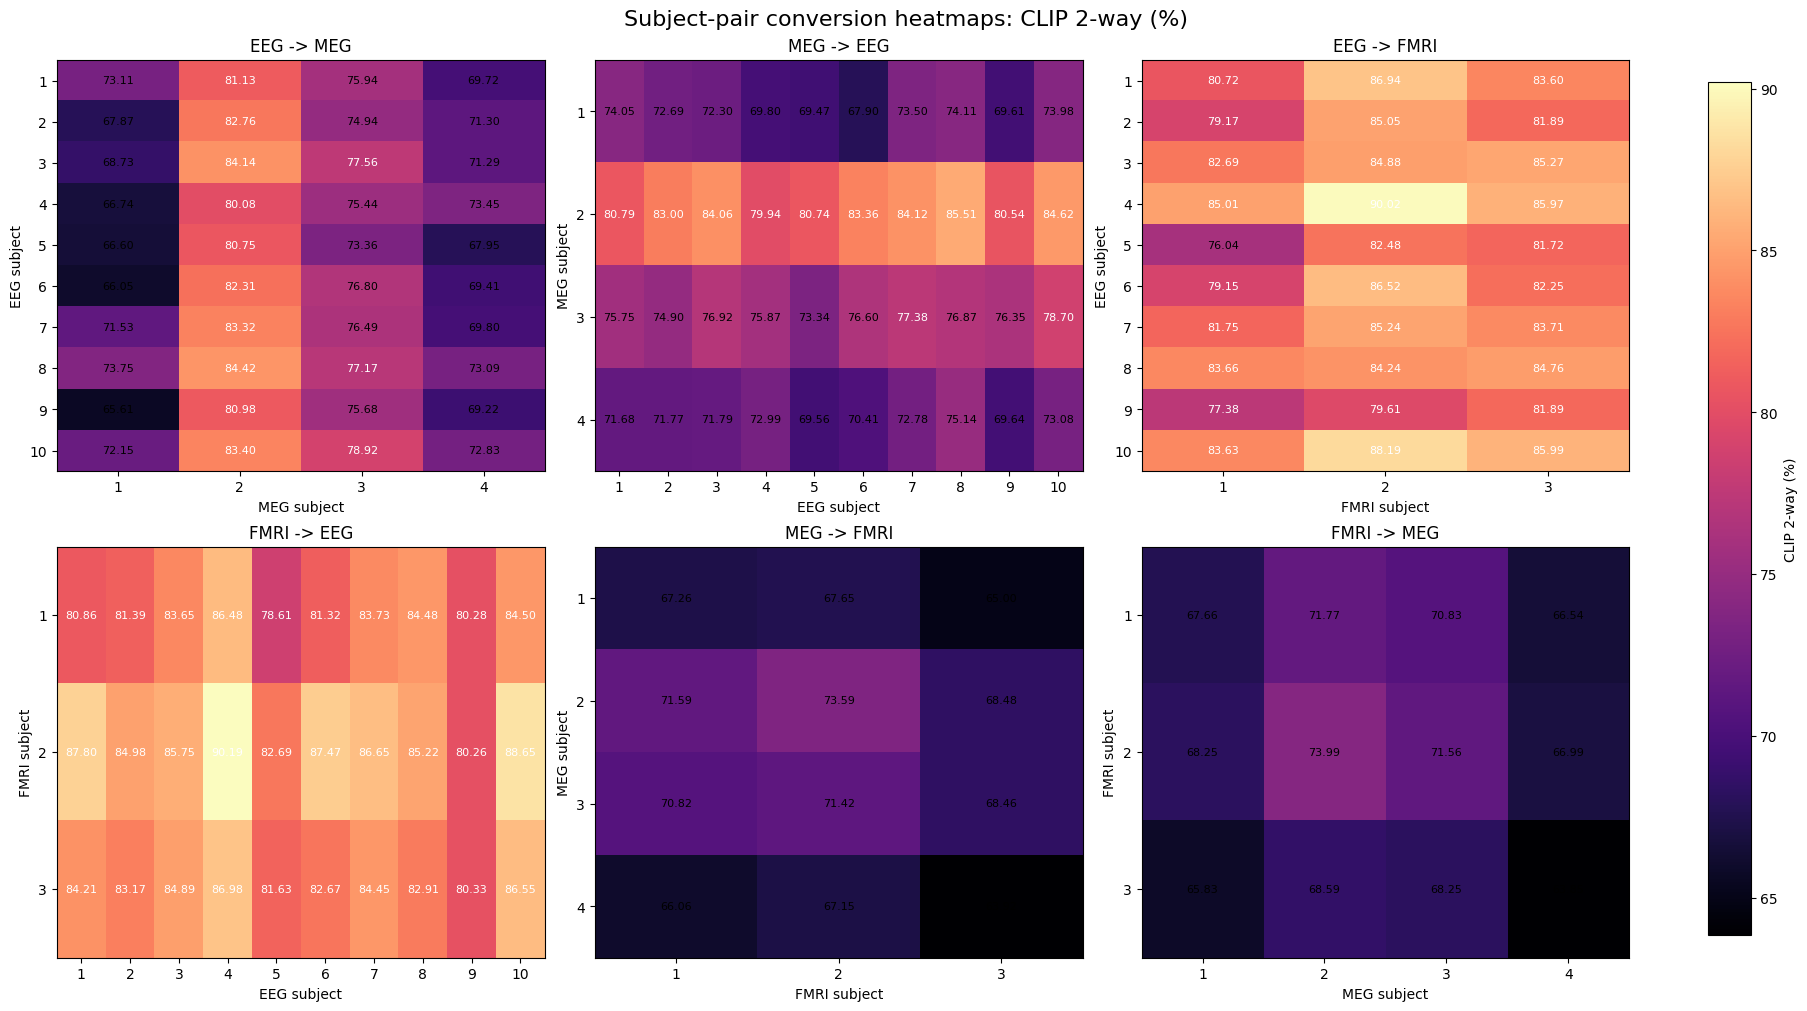

Saved ../results/summary/figures/subject_pair_heatmaps_normalized_two_way.png


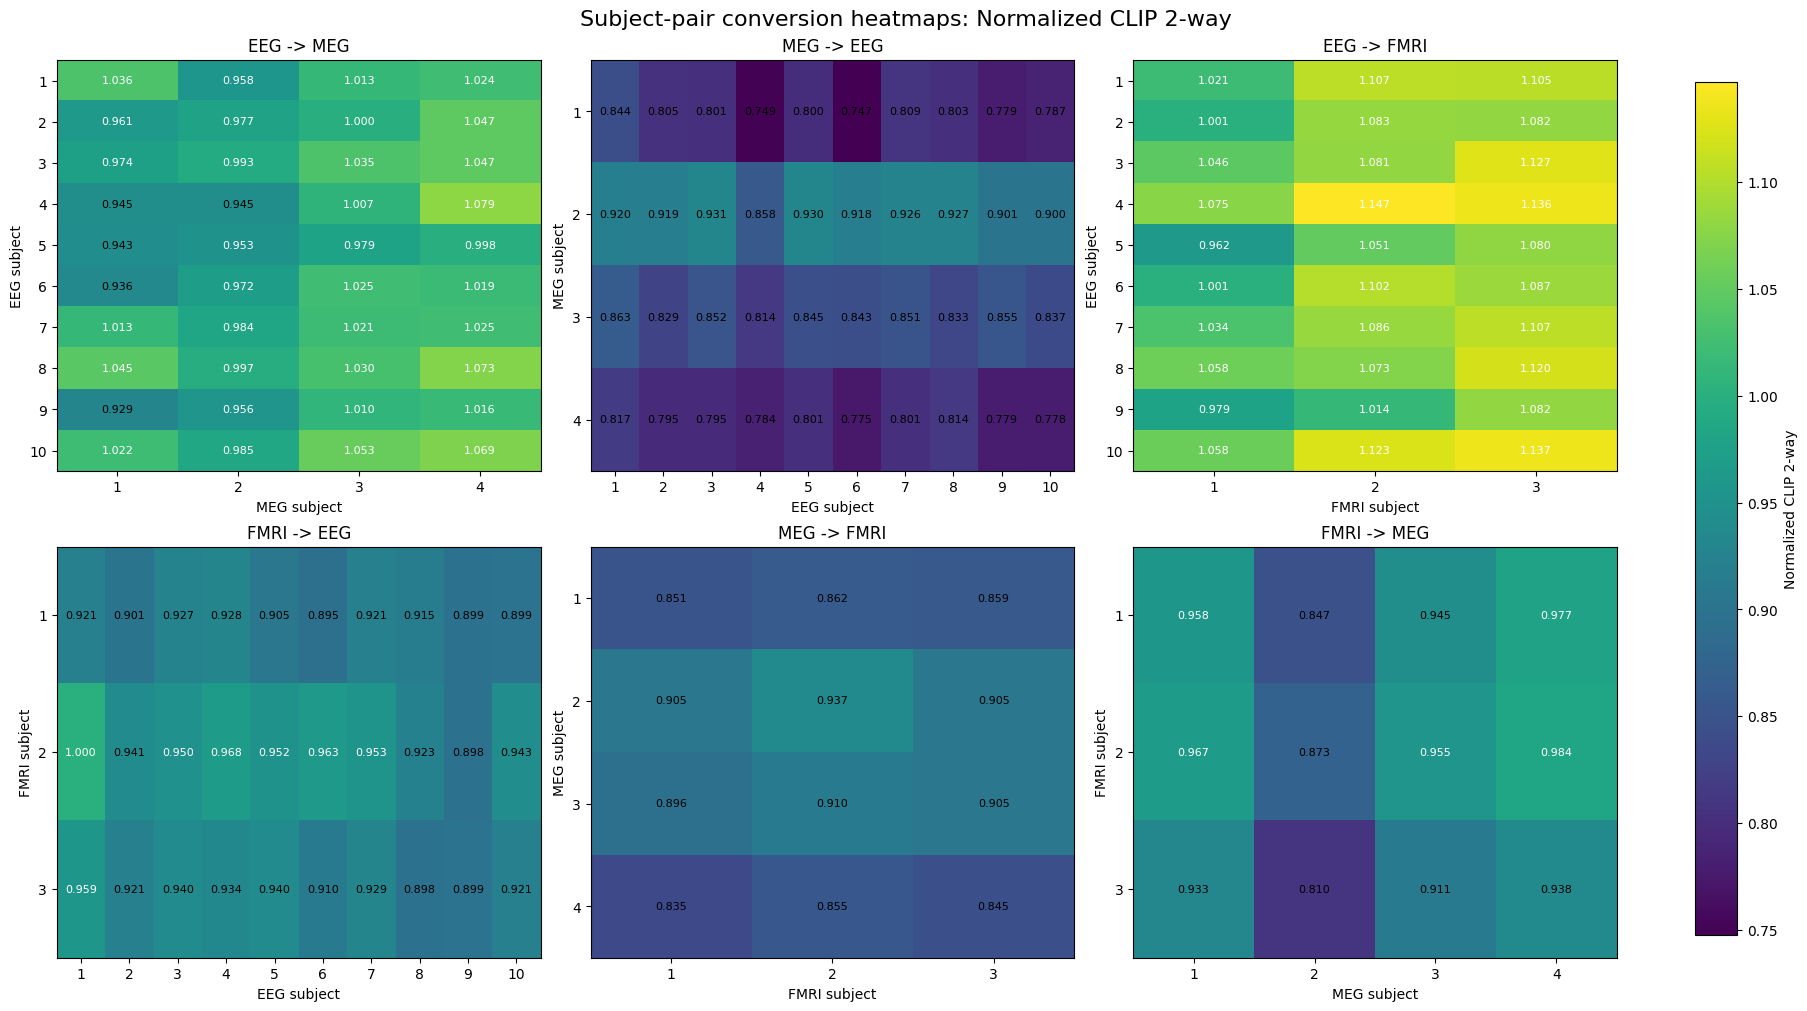

Saved ../results/summary/figures/subject_pair_heatmaps_top1.png


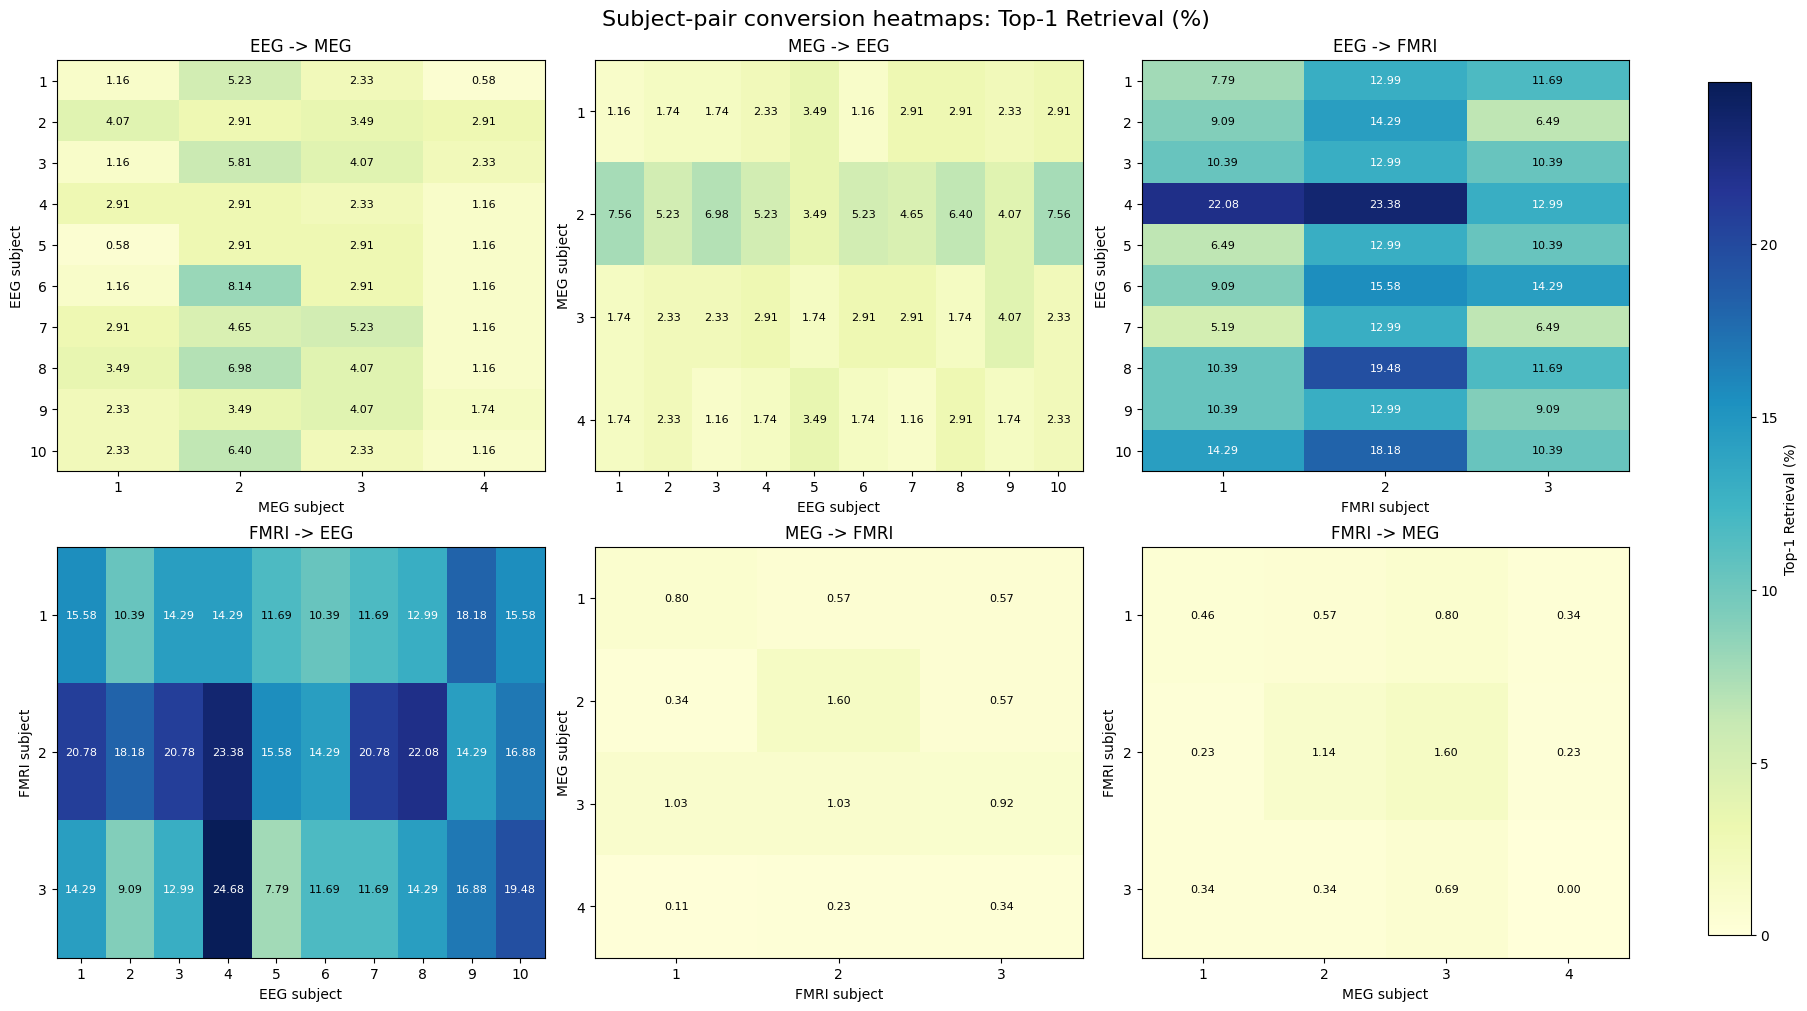

Saved ../results/summary/figures/subject_pair_heatmaps_top5.png


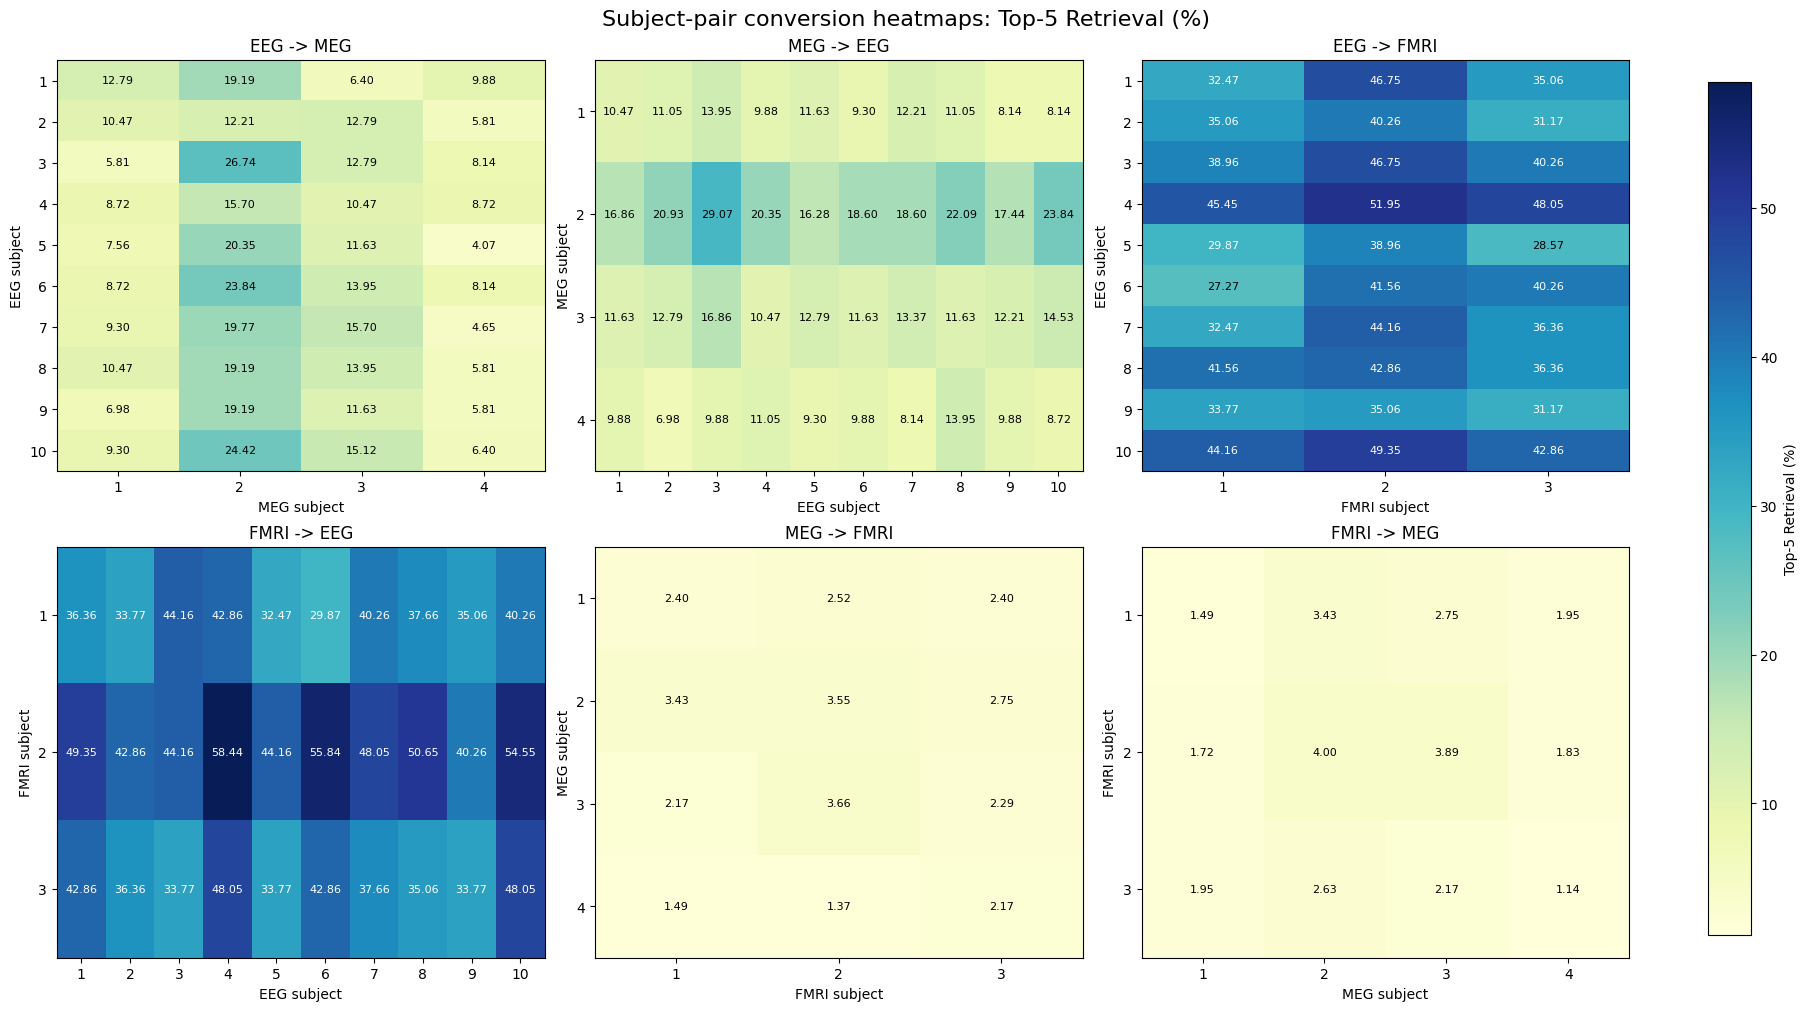

In [5]:
for metric_name in ['two_way', 'normalized_two_way', 'top1', 'top5']:
    plot_subject_pair_heatmaps(
        directed_df,
        metric_name,
        save_path=OUTPUT_DIR / f'subject_pair_heatmaps_{metric_name}.png',
    )

## Modality-level overview

These matrices collapse over subject pairs and show the mean ± std for each directed modality conversion.

Saved ../results/summary/figures/modality_overview_two_way.png


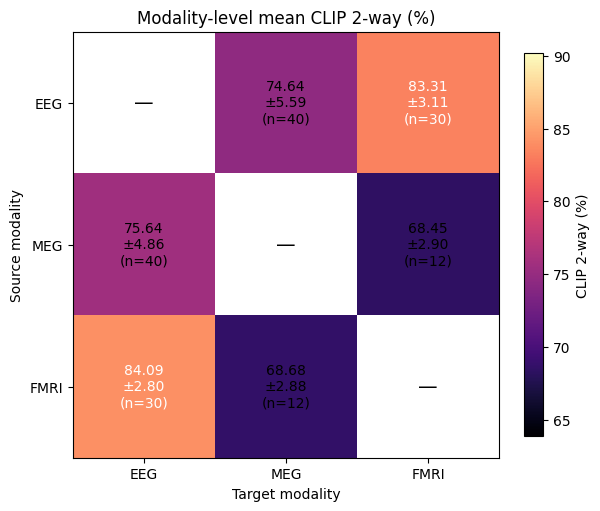

Saved ../results/summary/figures/modality_overview_normalized_two_way.png


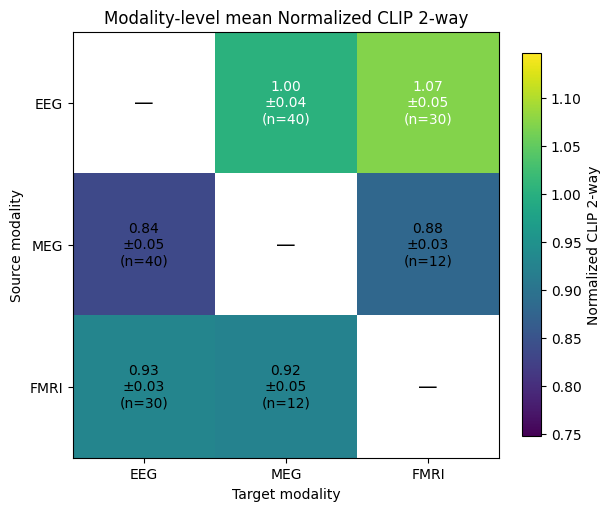

Saved ../results/summary/figures/modality_overview_top1.png


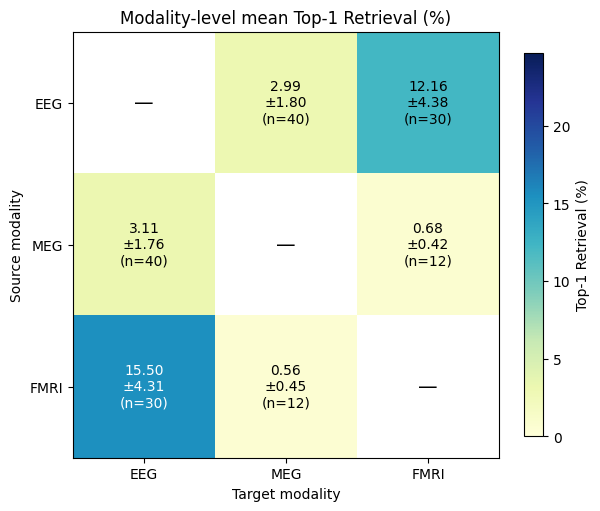

Saved ../results/summary/figures/modality_overview_top5.png


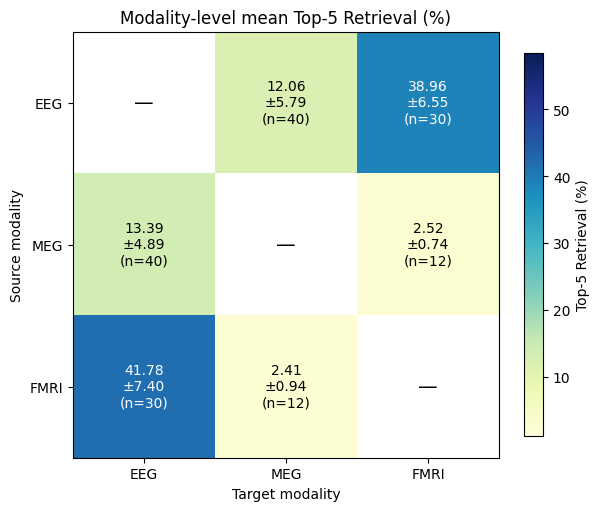

In [6]:
for metric_name in ['two_way', 'normalized_two_way', 'top1', 'top5']:
    plot_modality_overview(
        directed_df,
        metric_name,
        save_path=OUTPUT_DIR / f'modality_overview_{metric_name}.png',
    )

In [7]:
modality_summary(directed_df, 'two_way').sort_values(['source_modality', 'target_modality'])

,source_modality,target_modality,mean,std,count
0,eeg,fmri,83.314000,3.107360,30
1,eeg,meg,74.644750,5.591186,40
2,fmri,eeg,84.091667,2.798577,30
3,fmri,meg,68.675833,2.875702,12
4,meg,eeg,75.640250,4.859162,40
5,meg,fmri,68.450000,2.901404,12
